# MMF1921 (Summer 2025) - Project 1
 
 The purpose of this program is to implement the following factor models
 
     a) Multi-factor OLS regression
     b) Fama-French 3-factor model
     c) LASSO
     d) Best Subset Selection
 
 and to use these factor models to estimate the asset expected returns and covariance matrix. 
 
These parameters will then be used to test the out-of-sample performance using MVO to construct optimal portfolios.
 
 Use can use this template to write your program.

     Student Name: Alex Khadra, Jerome Charbonneau, Katie Chai
     Student ID: XX, 1012502025, 1005568066

In [1]:
!conda activate mmf1921

In [2]:
import time
import math
from scipy.stats import gmean
import matplotlib.pyplot as plt
from functions.BSS import *
from functions.FF import *
from functions.LASSO import *
from functions.MVO import *
from functions.OLS import *
import pandas as pd

adjClose = pd.read_csv("MMF1921_AssetPrices.csv", index_col=0)
factorRet = pd.read_csv("MMF1921_FactorReturns.csv", index_col=0)

(CVXPY) May 23 03:19:01 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.9.3963). Expected < 9.8.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) May 23 03:19:01 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.9.3963). Expected < 9.8.0. Please open a feature request on cvxpy to enable support for this version.')


In [3]:
adjClose.index = pd.to_datetime(adjClose.index)
factorRet.index = pd.to_datetime(factorRet.index)

In [4]:
#rf and factor returns
riskFree = factorRet['RF']
factorRet = factorRet.loc[:,factorRet.columns != 'RF'];

In [5]:
#Identify the tickers and the dates
tickers = adjClose.columns
dates   = factorRet.index

In [6]:
# Calculate the stocks monthly excess returns
# pct change and drop the first null observation
returns = adjClose.pct_change(1).iloc[1:, :]

returns = returns  - np.diag(riskFree.values) @ np.ones_like(returns.values)
# Align the price table to the asset and factor returns tables by discarding the first observation.
adjClose = adjClose.iloc[1:,:]

In [7]:
assert adjClose.index[0] == returns.index[0]
assert adjClose.index[0] == factorRet.index[0]

# 2. Define your initial parameters

In [8]:
#Initial budget to invest ($100,000)
initialVal = 100000

#Start of in-sample calibration period
calStart = pd.to_datetime('2008-01-01', format = '%Y-%m-%d')
calEnd   = calStart + pd.offsets.DateOffset(years=4) - pd.offsets.DateOffset(days=1)

#Start of out-of-sample test period
testStart = pd.to_datetime('2012-01-01', format = '%Y-%m-%d')
testEnd   = testStart + pd.offsets.DateOffset(years=1) - pd.offsets.DateOffset(days=1)

#Number of investment periods (each investment period is 1 year long)
NoPeriods = 5

#Factor models
#Note: You must populate the functions OLS.py, FF.py, LASSO.py and BSS.py with your own code.
# FMList = [OLS, FF, LASSO]
FMList = [OLS, FF, LASSO, BSS]
NoModels = len(FMList)

#Tags for the portfolios under the different factor models
tags = ['OLS portfolio', 'FF portfolio', 'LASSO portfolio', 'BSS portfolio']
# tags = ['OLS portfolio', 'FF portfolio', 'LASSO portfolio']

# 3. Construct and rebalance your portfolios

Here you will estimate your input parameters (exp. returns and cov. matrix etc) from the Fama-French factor models.
You will have to re-estimate your parameters at the start of each rebalance period, and then re-optimize and rebalance your portfolios accordingly.

Ensure you re-initialize the dates above if you run this cell repeatedly. 

In [9]:
# ── Reset dates before running the backtest ──
calStart = pd.to_datetime('2008-01-01', format='%Y-%m-%d')
calEnd   = calStart + pd.offsets.DateOffset(years=4) - pd.offsets.DateOffset(days=1)

testStart = pd.to_datetime('2012-01-01', format='%Y-%m-%d')
testEnd   = testStart + pd.offsets.DateOffset(years=1) - pd.offsets.DateOffset(days=1)

# ── λ tuning: run once on the first calibration window ──
lambda_grid = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
K = 4

tune_returns = returns[(pd.to_datetime('2008-01-01') <= returns.index) &
                       (returns.index <= pd.to_datetime('2011-12-31'))]

tune_factRet = factorRet[(pd.to_datetime('2008-01-01') <= factorRet.index) &
                         (factorRet.index <= pd.to_datetime('2011-12-31'))]

best_lambda, best_score = lambda_grid[0], np.inf

for lam in lambda_grid:
    _, _, B = LASSO(tune_returns, tune_factRet, lam, K, return_loadings=True)
    avg_nz = np.sum(np.abs(B) > 1e-4, axis=0).mean()
    print(f"lambda={lam:.4f} | avg non-zero coeffs: {avg_nz:.2f}")

    if abs(avg_nz - 3.5) < best_score:
        best_score = abs(avg_nz - 3.5)
        best_lambda = lam

print(f"\n→ Selected lambda: {best_lambda}")
lambda_ = best_lambda


# ── Main backtest loop ──
toDay = 0

currentVal = {i: np.zeros(NoPeriods) for i in range(NoModels)}
n = len(tickers)

x = {i: np.zeros([n, NoPeriods]) for i in range(NoModels)}

mu = {}
Q = {}
NoShares = {}

portfValue = {i: [] for i in range(NoModels)}

for t in range(NoPeriods):

    periodReturns = returns[(calStart <= returns.index) & (returns.index <= calEnd)]
    periodFactRet = factorRet[(calStart <= factorRet.index) & (factorRet.index <= calEnd)]

    current_price_idx = (calEnd - pd.offsets.DateOffset(days=7) <= adjClose.index) & \
                        (adjClose.index <= calEnd)
    currentPrices = adjClose[current_price_idx]

    periodPrices_idx = (testStart <= adjClose.index) & (adjClose.index <= testEnd)
    periodPrices = adjClose[periodPrices_idx]

    print("t =", t, "| calEnd =", calEnd, "| currentPrices length =", len(currentPrices))

    assert len(currentPrices) == 1

    currentPricesVec = currentPrices.iloc[0]

    if t == 0:
        for i in range(NoModels):
            currentVal[i][0] = initialVal
    else:
        for i in range(NoModels):
            currentVal[i][t] = (currentPricesVec @ NoShares[i].values.T).squeeze()

    fromDay = toDay
    toDay = toDay + len(periodPrices)

    for i in range(NoModels):
        mu[i], Q[i] = FMList[i](periodReturns, periodFactRet, lambda_, K)

    for i in range(NoModels):
        targetRet = gmean(periodFactRet.iloc[:, 0] + 1) - 1
        x[i][:, t] = MVO(mu[i], Q[i], targetRet)

    for i in range(NoModels):
        NoShares[i] = x[i][:, t] * currentVal[i][t] / currentPricesVec
        portfValue[i].append(periodPrices @ NoShares[i].values.T)

    calStart = calStart + pd.offsets.DateOffset(years=1)
    calEnd = calStart + pd.offsets.DateOffset(years=4) - pd.offsets.DateOffset(days=1)

    testStart = testStart + pd.offsets.DateOffset(years=1)
    testEnd = testStart + pd.offsets.DateOffset(years=1) - pd.offsets.DateOffset(days=1)


for i in range(NoModels):
    portfValue[i] = pd.concat(portfValue[i], axis=0)

portfValue = pd.DataFrame(
    [portfValue[i].values.squeeze() for i in range(NoModels)],
    index=tags,
    columns=portfValue[0].index
).T

lambda=0.0010 | avg non-zero coeffs: 8.60
lambda=0.0050 | avg non-zero coeffs: 7.35
lambda=0.0100 | avg non-zero coeffs: 6.30
lambda=0.0200 | avg non-zero coeffs: 4.80
lambda=0.0500 | avg non-zero coeffs: 3.05
lambda=0.1000 | avg non-zero coeffs: 2.15

→ Selected lambda: 0.05
t = 0 | calEnd = 2011-12-31 00:00:00 | currentPrices length = 1
USING EXHAUSTIVE SEARCH BSS
t = 1 | calEnd = 2012-12-31 00:00:00 | currentPrices length = 1
USING EXHAUSTIVE SEARCH BSS
t = 2 | calEnd = 2013-12-31 00:00:00 | currentPrices length = 1
USING EXHAUSTIVE SEARCH BSS
t = 3 | calEnd = 2014-12-31 00:00:00 | currentPrices length = 1
USING EXHAUSTIVE SEARCH BSS
t = 4 | calEnd = 2015-12-31 00:00:00 | currentPrices length = 1
USING EXHAUSTIVE SEARCH BSS


In [10]:
portfValue

,OLS portfolio,FF portfolio,LASSO portfolio,BSS portfolio
Date,,,,
2012-01-31,98591.215634,98413.389173,98523.597855,98628.909029
2012-02-29,98169.799657,97871.757888,98444.119094,97942.456851
2012-03-31,99661.609418,99187.470881,99799.137173,99224.568507
2012-04-30,99737.827597,99126.722834,99894.061378,99025.914445
2012-05-31,100976.848892,100259.519471,100214.219549,100295.805430
2012-06-30,104702.989533,104200.364786,104633.944349,104083.893545
2012-07-31,108375.995172,107846.839379,107994.168600,107735.689509
2012-08-31,105686.393146,105374.243727,105727.103354,105375.154613
2012-09-30,107136.967389,106628.893350,107655.791212,106589.254206


# 4. Results

In [11]:
#--------------------------------------------------------------------------
# 4.1 Evaluate any measures of fit of the regression models to assess their
# in-sample quality. You may want to modify Section 3 of this program to
# calculate the quality of fit each time the models are recalibrated.
#--------------------------------------------------------------------------

#--------------------------------------------------------------------------
# 4.2 Calculate the portfolio average return, variance (or standard 
# deviation), and any other performance and/or risk metric you wish to 
# include in your report.
#--------------------------------------------------------------------------

<Figure size 432x288 with 0 Axes>

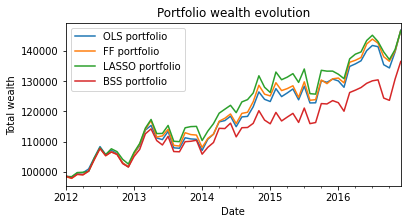

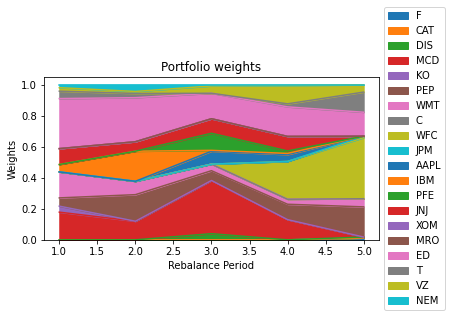

In [12]:
#--------------------------------------------------------------------------
# 4.3 Plot the portfolio wealth evolution 
# 
# Note: The code below plots all portfolios onto a single plot. However,
# you may want to split this into multiple plots for clarity, or to
# compare a subset of the portfolios. 
#--------------------------------------------------------------------------
# Calculate the dates of the out-of-sample period

fig = plt.figure(1)
portfValue.plot(title = 'Portfolio wealth evolution',
                ylabel = 'Total wealth',
                figsize = (6, 3),
                legend = True)
plt.savefig("images/wealth.svg")

#--------------------------------------------------------------------------
# 4.4 Plot the portfolio weights period-over-period
#--------------------------------------------------------------------------
# OLS Portfolio weights

fig2 = plt.figure(2)
x[0][x[0] < 0] = 0
weights = pd.DataFrame(x[0][(x[0] >0).any(axis=1)], index = tickers[(x[0] >0).any(axis=1)])
weights.columns = [col + 1 for col in weights.columns]
weights.T.plot.area(title = 'Portfolio weights',
                  ylabel = 'Weights', xlabel = 'Rebalance Period',
                  figsize = (6, 3),
                  legend = True, stacked = True)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.savefig("images/weights.svg")
#
# ###########################################################################
# # Program End